Loading data from multiple files...

Loading file 1/6: B:/Ephys.Pub/B05M/Numpy/B05.redo.All.Units.BF.npy
  Found 202 units

Loading file 2/6: B:/Ephys.Pub/CD3F/Process/CD3F.BFUnit.npy
  Found 328 units

Loading file 3/6: B:/Ephys.Pub/693F/693.Filtered.All.Units.BF.npy
  Found 321 units

Loading file 4/6: B:/Ephys.Pub/continuous_files/AF4.BF.Filtered.Units.npy
  Found 652 units

Loading file 5/6: B:/Ephys.Pub/continuous_files/AD6.BF.Filtered.Units.npy
  Found 533 units

Loading file 6/6: B:/Ephys.Pub/continuous_files/B03.BF.Filtered.Units.npy
  Found 143 units

Total units loaded from all files: 1915
Unique frequency bins found: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

Unified frequency bins: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

Creating unified firing rate matrix...

Building binary heatmap data (only showing best frequency)...

Total units after 0 Hz threshold: 1915
Units excluded: 0
Sort check - first 10 BFs: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
Sort c

C:\Users\Zaria\AppData\Local\Temp\ipykernel_8468\2114999269.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


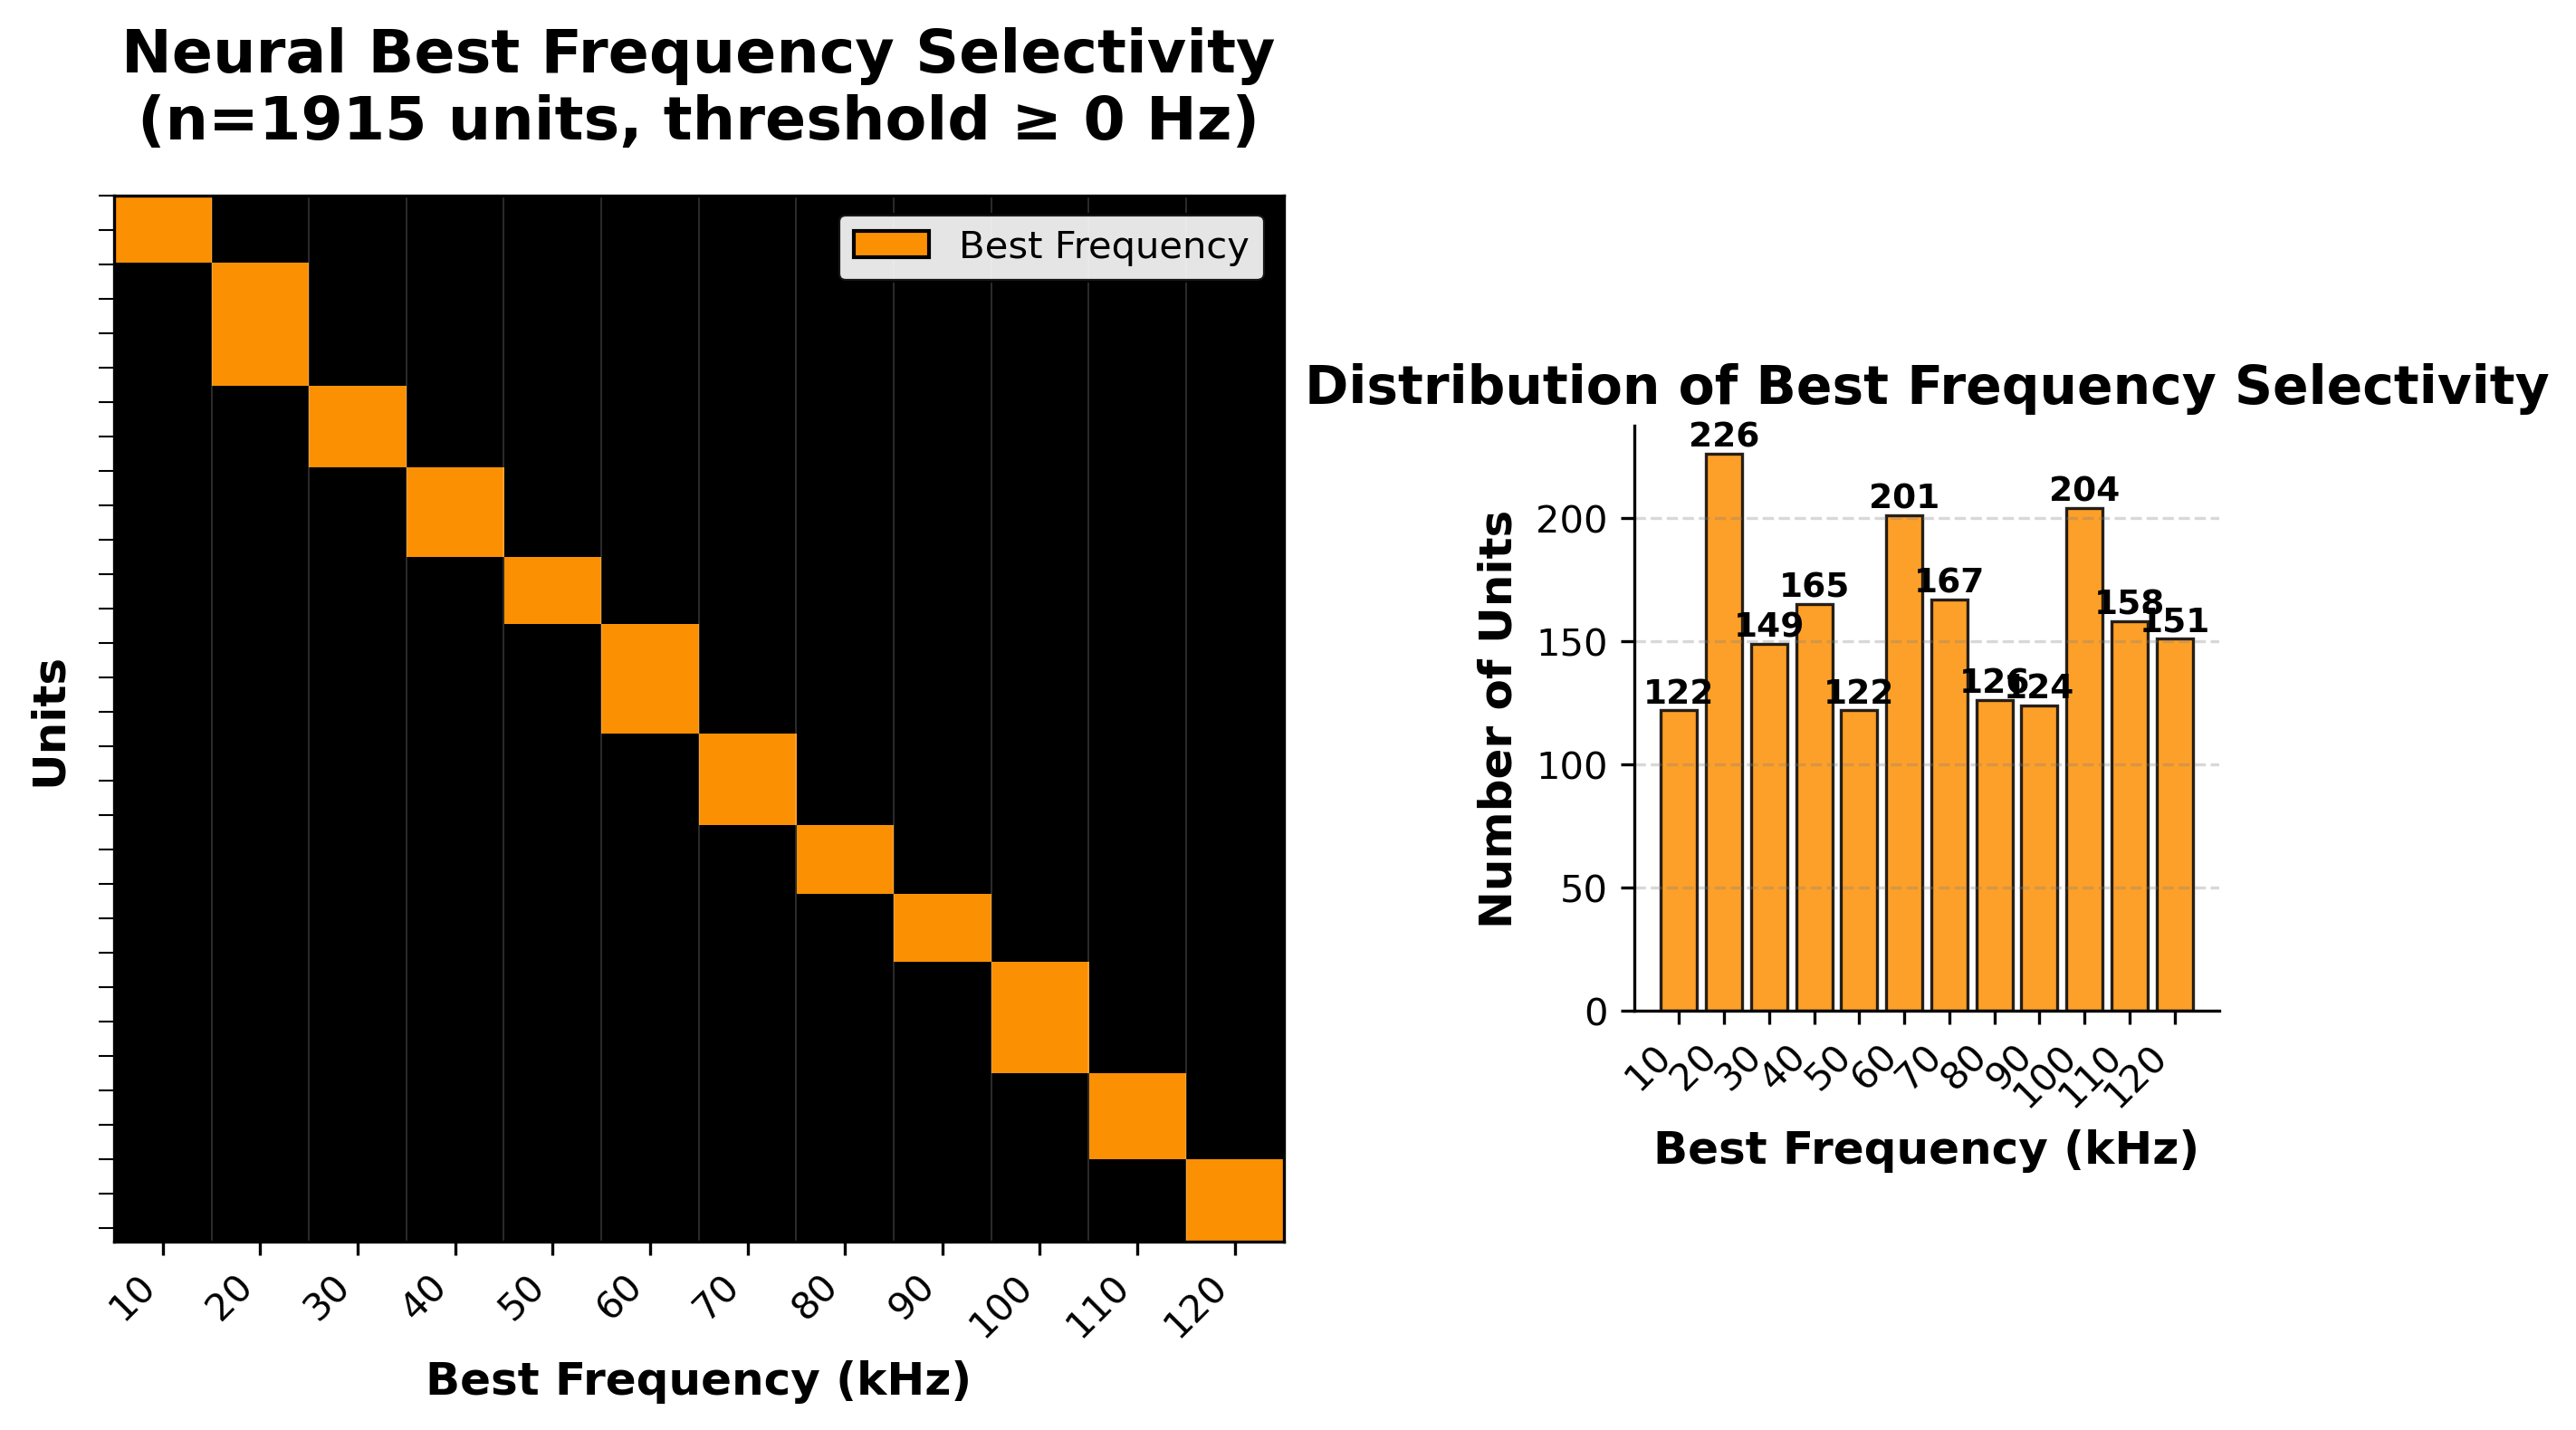


Figures saved to: ./frequency_tuning_figures

BINARY FREQUENCY SELECTIVITY SUMMARY (≥0 Hz)
Total units analyzed: 1915
Units excluded (firing rate < 0 Hz): 0
Frequency bins: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

Units per frequency bin (in order):
   10 kHz: 122 units (  6.4%)
   20 kHz: 226 units ( 11.8%)
   30 kHz: 149 units (  7.8%)
   40 kHz: 165 units (  8.6%)
   50 kHz: 122 units (  6.4%)
   60 kHz: 201 units ( 10.5%)
   70 kHz: 167 units (  8.7%)
   80 kHz: 126 units (  6.6%)
   90 kHz: 124 units (  6.5%)
  100 kHz: 204 units ( 10.7%)
  110 kHz: 158 units (  8.3%)
  120 kHz: 151 units (  7.9%)

Most common best frequency: 20 kHz (226 units)

Mean firing rate at best frequency for units tuned to each frequency:
   10 kHz:   5.30 Hz (n=122)
   20 kHz:   4.34 Hz (n=226)
   30 kHz:   5.26 Hz (n=149)
   40 kHz:   3.90 Hz (n=165)
   50 kHz:   5.48 Hz (n=122)
   60 kHz:   3.60 Hz (n=201)
   70 kHz:   4.51 Hz (n=167)
   80 kHz:   5.14 Hz (n=126)
   90 kHz:   5.05 Hz (n=12

In [1]:
#binary best frequency plot - show only BF response, rest black
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from collections import Counter, defaultdict
import os
import re

# ============ CONFIGURATION ============
INPUT_FILE_PATHS = [
    r'B:/Ephys.Pub/B05M/Numpy/B05.redo.All.Units.BF.npy',
    r'B:/Ephys.Pub/CD3F/Process/CD3F.BFUnit.npy',
    r'B:/Ephys.Pub/693F/693.Filtered.All.Units.BF.npy',
    r'B:/Ephys.Pub/continuous_files/AF4.BF.Filtered.Units.npy',
    r'B:/Ephys.Pub/continuous_files/AD6.BF.Filtered.Units.npy',
    r'B:/Ephys.Pub/continuous_files/B03.BF.Filtered.Units.npy',
]

OUTPUT_DIR = "./frequency_tuning_figures"

# Firing rate threshold - only include units with firing rate > this value at their best frequency
FIRING_RATE_THRESHOLD = 0 # Hz

# Warm orange from rocket palette
BF_COLOR = '#fc9003'

# ============ HELPER FUNCTION TO EXTRACT FREQUENCY ============
def extract_frequency_khz(stimulus_name):
    """
    Extract frequency in kHz from stimulus identifier.
    Examples: '10kHz_70dB' -> 10, '20kHz' -> 20, '35000Hz' -> 35
    """
    if isinstance(stimulus_name, (int, float)):
        return int(stimulus_name)

    stimulus_str = str(stimulus_name)

    khz_match = re.search(r'(\d+)kHz', stimulus_str, re.IGNORECASE)
    if khz_match:
        return int(khz_match.group(1))

    hz_match = re.search(r'(\d+)Hz', stimulus_str, re.IGNORECASE)
    if hz_match:
        return int(hz_match.group(1)) // 1000

    num_match = re.search(r'(\d+)', stimulus_str)
    if num_match:
        return int(num_match.group(1))

    return None

# ============ LOAD AND BIN DATA FROM MULTIPLE FILES ============
print("Loading data from multiple files...")

all_unit_data = {}
all_freq_bins = set()
unit_offset = 0

for file_idx, file_path in enumerate(INPUT_FILE_PATHS):
    try:
        print(f"\nLoading file {file_idx + 1}/{len(INPUT_FILE_PATHS)}: {file_path}")
        loaded_data = np.load(file_path, allow_pickle=True).item()

        file_stimulus_identifiers = loaded_data['stimulus_identifiers']
        file_unit_best_frequency = loaded_data['unit_best_frequency']
        file_unit_avg_firing_rates = loaded_data['unit_avg_firing_rates']

        num_units_in_file = len(file_unit_best_frequency)
        print(f"  Found {num_units_in_file} units")

        file_freq_bins = set()
        stim_to_freq_map = {}
        for stim in file_stimulus_identifiers:
            freq = extract_frequency_khz(stim)
            if freq is not None:
                file_freq_bins.add(freq)
                stim_to_freq_map[stim] = freq

        all_freq_bins.update(file_freq_bins)

        for original_id in sorted(file_unit_best_frequency.keys(),
                                  key=lambda x: int(x) if isinstance(x, str) and x.isdigit() else 0):

            new_id = str(unit_offset + int(original_id))

            best_freq_raw = file_unit_best_frequency[original_id]
            best_freq_binned = extract_frequency_khz(best_freq_raw)

            unit_rates = file_unit_avg_firing_rates[original_id]

            binned_rates = defaultdict(list)
            for stim, rate in zip(file_stimulus_identifiers, unit_rates):
                freq_bin = stim_to_freq_map.get(stim)
                if freq_bin is not None:
                    binned_rates[freq_bin].append(rate)

            averaged_binned_rates = {}
            for freq_bin in file_freq_bins:
                if freq_bin in binned_rates:
                    averaged_binned_rates[freq_bin] = np.mean(binned_rates[freq_bin])
                else:
                    averaged_binned_rates[freq_bin] = 0.0

            all_unit_data[new_id] = {
                'best_freq': best_freq_binned,
                'binned_rates': averaged_binned_rates
            }

        unit_offset += num_units_in_file

    except Exception as e:
        print(f"  ERROR loading {file_path}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print(f"Total units loaded from all files: {len(all_unit_data)}")
print(f"Unique frequency bins found: {sorted(all_freq_bins)}")
print(f"{'='*60}")

# ============ CREATE UNIFIED FREQUENCY BINS ============
unique_freqs = sorted(all_freq_bins)
print(f"\nUnified frequency bins: {unique_freqs}")

print("\nCreating unified firing rate matrix...")
for unit_id, unit_data in all_unit_data.items():
    binned_rates = unit_data['binned_rates']
    unit_rate_vector = []
    for freq in unique_freqs:
        if freq in binned_rates:
            unit_rate_vector.append(binned_rates[freq])
        else:
            unit_rate_vector.append(0.0)
    unit_data['rate_vector'] = unit_rate_vector

# ============ BUILD BINARY HEATMAP DATA ============
print("\nBuilding binary heatmap data (only showing best frequency)...")

unit_info = []
excluded_units = 0

for unit_id, unit_data in all_unit_data.items():
    best_freq = unit_data['best_freq']
    if best_freq is not None and best_freq in unique_freqs:
        best_freq_index = unique_freqs.index(best_freq)
        best_freq_rate = unit_data['rate_vector'][best_freq_index]

        if best_freq_rate >= FIRING_RATE_THRESHOLD:
            unit_info.append((unit_id, best_freq, best_freq_rate))
        else:
            excluded_units += 1
            print(f"  Excluded Unit {unit_id}: BF rate = {best_freq_rate:.2f} Hz < {FIRING_RATE_THRESHOLD} Hz")
    else:
        print(f"  Warning: Unit {unit_id} has invalid best frequency: {best_freq}")
        excluded_units += 1

print(f"\nTotal units after {FIRING_RATE_THRESHOLD} Hz threshold: {len(unit_info)}")
print(f"Units excluded: {excluded_units}")

# Sort by best frequency ascending (numeric), then firing rate descending within each group
unit_info_sorted = sorted(unit_info, key=lambda x: (int(x[1]), -x[2]))

# Debug sort check
print("Sort check - first 10 BFs:", [x[1] for x in unit_info_sorted[:10]])
print("Sort check - last 10 BFs:",  [x[1] for x in unit_info_sorted[-10:]])

# Build binary matrix: 1 where BF, 0 everywhere else
heatmap_data   = np.zeros((len(unit_info_sorted), len(unique_freqs)))  # kept for summary stats
binary_display = np.zeros((len(unit_info_sorted), len(unique_freqs)), dtype=float)

sorted_unit_labels = []
sorted_best_freqs  = []

for row_idx, (unit_id, best_freq, best_freq_rate) in enumerate(unit_info_sorted):
    bf_col_idx = unique_freqs.index(best_freq)
    heatmap_data[row_idx, bf_col_idx]   = best_freq_rate
    binary_display[row_idx, bf_col_idx] = 1.0
    sorted_unit_labels.append(f"Unit {unit_id}")
    sorted_best_freqs.append(best_freq)

print(f"Binary heatmap shape: {binary_display.shape}")
print(f"(Units: {binary_display.shape[0]}, Frequencies: {binary_display.shape[1]})")

# ============ COUNT UNITS PER FREQUENCY ============
bf_counter = Counter(sorted_best_freqs)
print("\nUnits selective for each frequency (in order):")
for freq in unique_freqs:
    if freq in bf_counter:
        print(f"  {freq:>3} kHz: {bf_counter[freq]:>3} units")

# ============ CREATE FIGURE ============
print("\nCreating binary frequency tuning heatmap...")

      

fig = plt.figure(figsize=(10, 5), dpi=300)
fig.patch.set_facecolor('white')    
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.4)

ax_heat = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1])

# Two-color colormap: black (0) -> warm orange (1)
binary_cmap = ListedColormap(['black', BF_COLOR])

ax_heat.imshow(
    binary_display,
    cmap=binary_cmap,
    vmin=0, vmax=1,
    aspect='auto',
    interpolation='nearest'
)

# Legend
legend_patch = mpatches.Patch(facecolor=BF_COLOR, edgecolor='black', label='Best Frequency')
ax_heat.legend(handles=[legend_patch], loc='upper right', fontsize=10,
               framealpha=0.9, facecolor='white', labelcolor='black', edgecolor='black')

# Y-axis: tick marks only, no labels
tick_interval = max(1, len(binary_display) // 30)
ax_heat.set_yticks(np.arange(0, len(binary_display), tick_interval))
ax_heat.set_yticklabels([])
ax_heat.tick_params(axis='y', length=4, width=0.5, colors='black')
ax_heat.tick_params(axis='x', colors='black')

# X-axis
ax_heat.set_xticks(np.arange(len(unique_freqs)))
ax_heat.set_xticklabels([f"{f}" for f in unique_freqs], rotation=45, ha='right', fontsize=10, color='black')

# Subtle vertical grid lines to separate frequency columns
for i in range(len(unique_freqs) + 1):
    ax_heat.axvline(x=i - 0.5, color='white', linewidth=0.4, alpha=0.2)

ax_heat.set_title(
    f'Neural Best Frequency Selectivity\n(n={len(sorted_best_freqs)} units, threshold ≥ {FIRING_RATE_THRESHOLD} Hz)',
    fontsize=16, fontweight='bold', pad=15, color='black'
)
ax_heat.set_xlabel('Best Frequency (kHz)', fontsize=12, fontweight='bold', color='black')
ax_heat.set_ylabel('Units', fontsize=12, fontweight='bold', color='black')
ax_heat.spines[['top', 'right', 'left', 'bottom']].set_color('black')

# --- Histogram ---

ax_hist.set_facecolor('white')            # white background for histogram
ax_hist.set_box_aspect(1)

freq_counts = [bf_counter.get(freq, 0) for freq in unique_freqs]

bars = ax_hist.bar(range(len(unique_freqs)), freq_counts,
                    color=BF_COLOR, alpha=0.85, edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, freq_counts):
    if count > 0:
        ax_hist.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                     f'{count}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

ax_hist.set_xticks(range(len(unique_freqs)))
ax_hist.set_xticklabels([f"{f}" for f in unique_freqs], rotation=45, ha='right', fontsize=10, color='black')
ax_hist.set_xlabel('Best Frequency (kHz)', fontsize=12, fontweight='bold', color='black')
ax_hist.set_ylabel('Number of Units', fontsize=12, fontweight='bold', color='black')
ax_hist.set_title('Distribution of Best Frequency Selectivity', fontsize=14, fontweight='bold', color='black')
ax_hist.grid(axis='y', alpha=0.3, linestyle='--', color='gray')
ax_hist.tick_params(axis='both', colors='black')
ax_hist.spines[['top', 'right']].set_visible(False)
ax_hist.spines[['left', 'bottom']].set_color('black')

# ============ SAVE ============
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "frequency_tuning_binary_heatmap.png"), dpi=300,
            bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUTPUT_DIR, "frequency_tuning_binary_heatmap.pdf"),
            bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nFigures saved to: {OUTPUT_DIR}")

# ============ SUMMARY STATISTICS ============
print("\n" + "="*60)
print(f"BINARY FREQUENCY SELECTIVITY SUMMARY (≥{FIRING_RATE_THRESHOLD} Hz)")
print("="*60)
print(f"Total units analyzed: {len(sorted_best_freqs)}")
print(f"Units excluded (firing rate < {FIRING_RATE_THRESHOLD} Hz): {excluded_units}")
print(f"Frequency bins: {unique_freqs}")
print(f"\nUnits per frequency bin (in order):")
for freq in unique_freqs:
    if freq in bf_counter:
        percentage = 100 * bf_counter[freq] / len(sorted_best_freqs) if len(sorted_best_freqs) > 0 else 0
        print(f"  {freq:>3} kHz: {bf_counter[freq]:>3} units ({percentage:>5.1f}%)")

if bf_counter:
    most_common_freq = max(bf_counter.items(), key=lambda x: x[1])
    print(f"\nMost common best frequency: {most_common_freq[0]} kHz ({most_common_freq[1]} units)")

print(f"\nMean firing rate at best frequency for units tuned to each frequency:")
for freq in unique_freqs:
    freq_idx = unique_freqs.index(freq)
    freq_units = [i for i, bf in enumerate(sorted_best_freqs) if bf == freq]
    if freq_units:
        rates = [heatmap_data[i, freq_idx] for i in freq_units]
        print(f"  {freq:>3} kHz: {np.mean(rates):>6.2f} Hz (n={len(rates)})")

print("\n" + "="*60)

Loading data from multiple files...

Loading file 1/6: B:/Ephys.Pub/B05M/Numpy/B05.redo.All.Units.BF.npy
  Found 202 units

Loading file 2/6: B:/Ephys.Pub/CD3F/Process/CD3F.BFUnit.npy
  Found 328 units

Loading file 3/6: B:/Ephys.Pub/693F/693.Filtered.All.Units.BF.npy
  Found 321 units

Loading file 4/6: B:/Ephys.Pub/continuous_files/AF4.BF.Filtered.Units.npy
  Found 652 units

Loading file 5/6: B:/Ephys.Pub/continuous_files/AD6.BF.Filtered.Units.npy
  Found 533 units

Loading file 6/6: B:/Ephys.Pub/continuous_files/B03.BF.Filtered.Units.npy
  Found 143 units

Total units loaded from all files: 1915
Unique frequency bins found: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

Unified frequency bins: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

Creating unified firing rate matrix...

Building binary heatmap data (only showing best frequency)...

Total units after 0 Hz threshold: 1915
Units excluded: 0
Binary heatmap shape: (1915, 12)

Creating binary frequency tuning heatmap

C:\Users\Zaria\AppData\Local\Temp\ipykernel_15544\2605064977.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


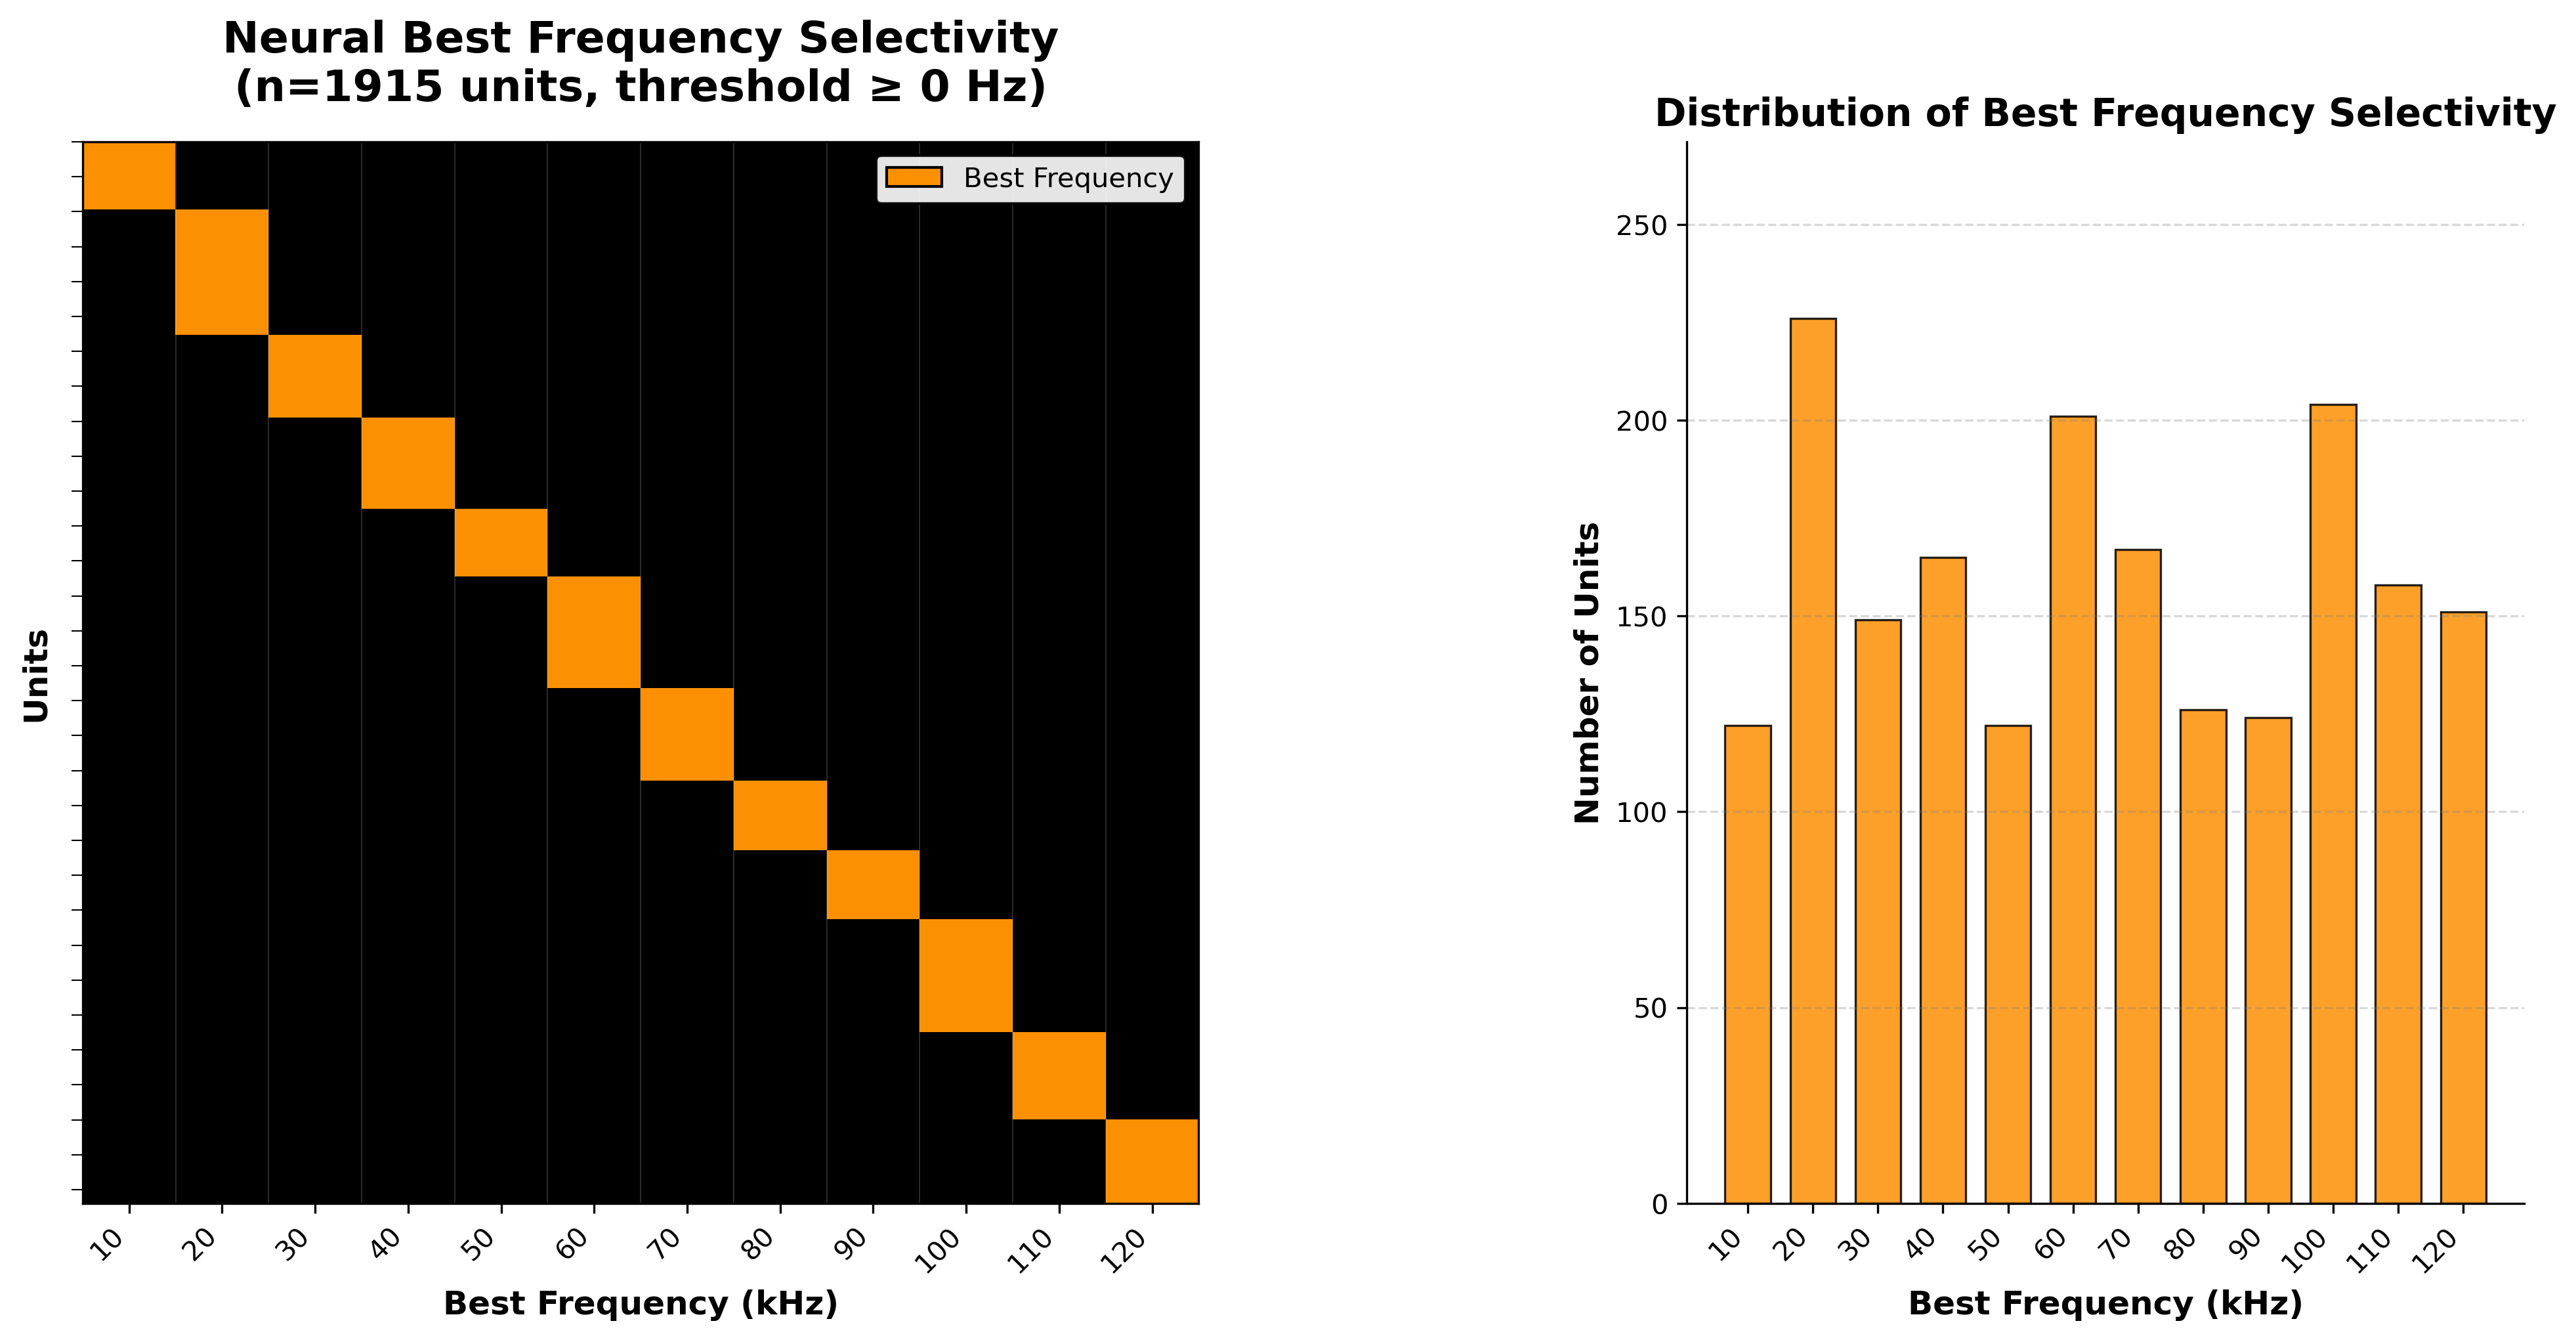


Figures saved to: ./frequency_tuning_figures


In [1]:

#binary best frequency plot - show only BF response, rest black
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from collections import Counter, defaultdict
import os
import re

# ============ CONFIGURATION ============
INPUT_FILE_PATHS = [
    r'B:/Ephys.Pub/B05M/Numpy/B05.redo.All.Units.BF.npy',
    r'B:/Ephys.Pub/CD3F/Process/CD3F.BFUnit.npy',
    r'B:/Ephys.Pub/693F/693.Filtered.All.Units.BF.npy',
    r'B:/Ephys.Pub/continuous_files/AF4.BF.Filtered.Units.npy',
    r'B:/Ephys.Pub/continuous_files/AD6.BF.Filtered.Units.npy',
    r'B:/Ephys.Pub/continuous_files/B03.BF.Filtered.Units.npy',
]

OUTPUT_DIR = "./frequency_tuning_figures"

# Firing rate threshold - only include units with firing rate > this value at their best frequency
FIRING_RATE_THRESHOLD = 0 # Hz

# Warm orange from rocket palette
BF_COLOR = '#fc9003'

# ============ HELPER FUNCTION TO EXTRACT FREQUENCY ============
def extract_frequency_khz(stimulus_name):
    """
    Extract frequency in kHz from stimulus identifier.
    Examples: '10kHz_70dB' -> 10, '20kHz' -> 20, '35000Hz' -> 35
    """
    if isinstance(stimulus_name, (int, float)):
        return int(stimulus_name)

    stimulus_str = str(stimulus_name)

    khz_match = re.search(r'(\d+)kHz', stimulus_str, re.IGNORECASE)
    if khz_match:
        return int(khz_match.group(1))

    hz_match = re.search(r'(\d+)Hz', stimulus_str, re.IGNORECASE)
    if hz_match:
        return int(hz_match.group(1)) // 1000

    num_match = re.search(r'(\d+)', stimulus_str)
    if num_match:
        return int(num_match.group(1))

    return None

# ============ LOAD AND BIN DATA FROM MULTIPLE FILES ============
print("Loading data from multiple files...")

all_unit_data = {}
all_freq_bins = set()
unit_offset = 0

for file_idx, file_path in enumerate(INPUT_FILE_PATHS):
    try:
        print(f"\nLoading file {file_idx + 1}/{len(INPUT_FILE_PATHS)}: {file_path}")
        loaded_data = np.load(file_path, allow_pickle=True).item()

        file_stimulus_identifiers = loaded_data['stimulus_identifiers']
        file_unit_best_frequency = loaded_data['unit_best_frequency']
        file_unit_avg_firing_rates = loaded_data['unit_avg_firing_rates']

        num_units_in_file = len(file_unit_best_frequency)
        print(f"  Found {num_units_in_file} units")

        file_freq_bins = set()
        stim_to_freq_map = {}
        for stim in file_stimulus_identifiers:
            freq = extract_frequency_khz(stim)
            if freq is not None:
                file_freq_bins.add(freq)
                stim_to_freq_map[stim] = freq

        all_freq_bins.update(file_freq_bins)

        for original_id in sorted(file_unit_best_frequency.keys(),
                                  key=lambda x: int(x) if isinstance(x, str) and x.isdigit() else 0):

            new_id = str(unit_offset + int(original_id))

            best_freq_raw = file_unit_best_frequency[original_id]
            best_freq_binned = extract_frequency_khz(best_freq_raw)

            unit_rates = file_unit_avg_firing_rates[original_id]

            binned_rates = defaultdict(list)
            for stim, rate in zip(file_stimulus_identifiers, unit_rates):
                freq_bin = stim_to_freq_map.get(stim)
                if freq_bin is not None:
                    binned_rates[freq_bin].append(rate)

            averaged_binned_rates = {}
            for freq_bin in file_freq_bins:
                if freq_bin in binned_rates:
                    averaged_binned_rates[freq_bin] = np.mean(binned_rates[freq_bin])
                else:
                    averaged_binned_rates[freq_bin] = 0.0

            all_unit_data[new_id] = {
                'best_freq': best_freq_binned,
                'binned_rates': averaged_binned_rates
            }

        unit_offset += num_units_in_file

    except Exception as e:
        print(f"  ERROR loading {file_path}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*60}")
print(f"Total units loaded from all files: {len(all_unit_data)}")
print(f"Unique frequency bins found: {sorted(all_freq_bins)}")
print(f"{'='*60}")

# ============ CREATE UNIFIED FREQUENCY BINS ============
unique_freqs = sorted(all_freq_bins)
print(f"\nUnified frequency bins: {unique_freqs}")

print("\nCreating unified firing rate matrix...")
for unit_id, unit_data in all_unit_data.items():
    binned_rates = unit_data['binned_rates']
    unit_rate_vector = []
    for freq in unique_freqs:
        if freq in binned_rates:
            unit_rate_vector.append(binned_rates[freq])
        else:
            unit_rate_vector.append(0.0)
    unit_data['rate_vector'] = unit_rate_vector

# ============ BUILD BINARY HEATMAP DATA ============
print("\nBuilding binary heatmap data (only showing best frequency)...")

unit_info = []
excluded_units = 0

for unit_id, unit_data in all_unit_data.items():
    best_freq = unit_data['best_freq']
    if best_freq is not None and best_freq in unique_freqs:
        best_freq_index = unique_freqs.index(best_freq)
        best_freq_rate = unit_data['rate_vector'][best_freq_index]

        if best_freq_rate >= FIRING_RATE_THRESHOLD:
            unit_info.append((unit_id, best_freq, best_freq_rate))
        else:
            excluded_units += 1
            print(f"  Excluded Unit {unit_id}: BF rate = {best_freq_rate:.2f} Hz < {FIRING_RATE_THRESHOLD} Hz")
    else:
        print(f"  Warning: Unit {unit_id} has invalid best frequency: {best_freq}")
        excluded_units += 1

print(f"\nTotal units after {FIRING_RATE_THRESHOLD} Hz threshold: {len(unit_info)}")
print(f"Units excluded: {excluded_units}")

# Sort by best frequency ascending (numeric), then firing rate descending within each group
unit_info_sorted = sorted(unit_info, key=lambda x: (int(x[1]), -x[2]))

# Build binary matrix
heatmap_data   = np.zeros((len(unit_info_sorted), len(unique_freqs)))
binary_display = np.zeros((len(unit_info_sorted), len(unique_freqs)), dtype=float)

sorted_unit_labels = []
sorted_best_freqs  = []

for row_idx, (unit_id, best_freq, best_freq_rate) in enumerate(unit_info_sorted):
    bf_col_idx = unique_freqs.index(best_freq)
    heatmap_data[row_idx, bf_col_idx]   = best_freq_rate
    binary_display[row_idx, bf_col_idx] = 1.0
    sorted_unit_labels.append(f"Unit {unit_id}")
    sorted_best_freqs.append(best_freq)

print(f"Binary heatmap shape: {binary_display.shape}")

# ============ COUNT UNITS PER FREQUENCY ============
bf_counter = Counter(sorted_best_freqs)

# ============ CREATE FIGURE ============
print("\nCreating binary frequency tuning heatmap...")

# BIGGER FIGURE
fig = plt.figure(figsize=(16, 7), dpi=300)
fig.patch.set_facecolor('white')

# GIVE HISTOGRAM MORE SPACE
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1.5], wspace=0.5)

ax_heat = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1])

# Two-color colormap
binary_cmap = ListedColormap(['black', BF_COLOR])

ax_heat.imshow(
    binary_display,
    cmap=binary_cmap,
    vmin=0,
    vmax=1,
    aspect='auto',
    interpolation='nearest'
)

# Legend
legend_patch = mpatches.Patch(
    facecolor=BF_COLOR,
    edgecolor='black',
    label='Best Frequency'
)

ax_heat.legend(
    handles=[legend_patch],
    loc='upper right',
    fontsize=10,
    framealpha=0.9,
    facecolor='white',
    labelcolor='black',
    edgecolor='black'
)

# Y-axis
tick_interval = max(1, len(binary_display) // 30)

ax_heat.set_yticks(np.arange(0, len(binary_display), tick_interval))
ax_heat.set_yticklabels([])

ax_heat.tick_params(axis='y', length=4, width=0.5, colors='black')
ax_heat.tick_params(axis='x', colors='black')

# X-axis
ax_heat.set_xticks(np.arange(len(unique_freqs)))

ax_heat.set_xticklabels(
    [f"{f}" for f in unique_freqs],
    rotation=45,
    ha='right',
    fontsize=10,
    color='black'
)

# Grid lines
for i in range(len(unique_freqs) + 1):
    ax_heat.axvline(
        x=i - 0.5,
        color='white',
        linewidth=0.4,
        alpha=0.2
    )

ax_heat.set_title(
    f'Neural Best Frequency Selectivity\n'
    f'(n={len(sorted_best_freqs)} units, threshold ≥ {FIRING_RATE_THRESHOLD} Hz)',
    fontsize=16,
    fontweight='bold',
    pad=15,
    color='black'
)

ax_heat.set_xlabel(
    'Best Frequency (kHz)',
    fontsize=12,
    fontweight='bold',
    color='black'
)

ax_heat.set_ylabel(
    'Units',
    fontsize=12,
    fontweight='bold',
    color='black'
)

ax_heat.spines[['top', 'right', 'left', 'bottom']].set_color('black')

# ================= HISTOGRAM =================

ax_hist.set_facecolor('white')

freq_counts = [bf_counter.get(freq, 0) for freq in unique_freqs]

# thinner bars with more spacing
bars = ax_hist.bar(
    range(len(unique_freqs)),
    freq_counts,
    width=0.7,
    color=BF_COLOR,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8
)

# labels above bars
# for bar, count in zip(bars, freq_counts):
#     if count > 0:
#         ax_hist.text(
#             bar.get_x() + bar.get_width() / 2.,
#             bar.get_height() + 0.5,
#             f'{count}',
#             ha='center',
#             va='bottom',
#             fontsize=7,
#             fontweight='bold',
#             color='black'
#         )

ax_hist.set_xticks(range(len(unique_freqs)))

ax_hist.set_xticklabels(
    [f"{f}" for f in unique_freqs],
    rotation=45,
    ha='right',
    fontsize=10,
    color='black'
)

# add headroom above bars
ax_hist.set_ylim(0, max(freq_counts) * 1.2)

ax_hist.set_xlabel(
    'Best Frequency (kHz)',
    fontsize=12,
    fontweight='bold',
    color='black'
)

ax_hist.set_ylabel(
    'Number of Units',
    fontsize=12,
    fontweight='bold',
    color='black'
)

ax_hist.set_title(
    'Distribution of Best Frequency Selectivity',
    fontsize=14,
    fontweight='bold',
    color='black'
)

ax_hist.grid(
    axis='y',
    alpha=0.3,
    linestyle='--',
    color='gray'
)

ax_hist.tick_params(axis='both', colors='black')

ax_hist.spines[['top', 'right']].set_visible(False)
ax_hist.spines[['left', 'bottom']].set_color('black')

# ============ SAVE ============
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "frequency_tuning_binary_heatmap.png"),
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.savefig(
    os.path.join(OUTPUT_DIR, "frequency_tuning_binary_heatmap.pdf"),
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(f"\nFigures saved to: {OUTPUT_DIR}")

